<a href="https://colab.research.google.com/github/monokizs/MI/blob/main/FruitSense.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ Siker! A modell betöltve a Legacy Keras-szal.


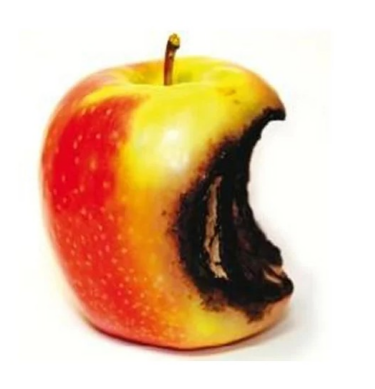


Eredmény: Apple (61.9%)
Kalória: 52 kcal


In [ ]:
# 1. LÉPÉS: A régi Keras kényszerítése (Futtasd le ezt, majd indítsd újra a Runtime-ot ha kéri)
!pip install tf_keras
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tensorflow as tf
import tf_keras as keras # A régi kerast használjuk
from PIL import Image, ImageOps
import numpy as np
import json
import matplotlib.pyplot as plt

# --- KONFIGURÁCIÓ ---
folder_path = '/content/drive/MyDrive/MI/RPI20260318/FruitSense/FruitSenseColab/'
json_path = folder_path + 'nutrition.json'
model_path = folder_path + 'keras_model.h5'
image_path = folder_path + 'test_apple2.jpg'

try:
    with open(json_path, 'r', encoding='utf-8') as f:
        data_store = json.load(f)

    # A tf_keras-t használjuk a betöltéshez
    model = keras.models.load_model(model_path, compile=False)
    print("✅ Siker! A modell betöltve a Legacy Keras-szal.")

    # Kép betöltése és jóslás
    if os.path.exists(image_path):
        image = Image.open(image_path).convert("RGB")
        plt.imshow(image); plt.axis('off'); plt.show()

        size = (224, 224)
        image_prep = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
        img_array = (np.asarray(image_prep).astype(np.float32) / 127.5) - 1
        data = np.expand_dims(img_array, axis=0)

        prediction = model.predict(data, verbose=0)
        labels = ["Apple", "Banana"]
        idx = np.argmax(prediction)

        print(f"\nEredmény: {labels[idx]} ({prediction[0][idx]*100:.1f}%)")
        print(f"Kalória: {data_store[labels[idx]]['calories']} kcal")
    else:
        print(f"❌ A kép még mindig hiányzik: {image_path}")

except Exception as e:
    print(f"❌ Még mindig hiba van: {e}")

Rendszer indítása...
✅ Adatbázis (JSON) betöltve.
❌ Hiba a betöltés során: Exception encountered when calling Sequential.call().

Layer "functional_24" expects 1 input(s), but it received 2 input tensors. Inputs received: [<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_823>, <KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_824>]

Arguments received by Sequential.call():
  • args=(('<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_823>', '<KerasTensor shape=(None, 7, 7, 1280), dtype=float32, sparse=False, ragged=False, name=keras_tensor_824>'),)
  • kwargs={'mask': ('None', 'None')}
Ellenőrizd az elérési utat a Drive-on!


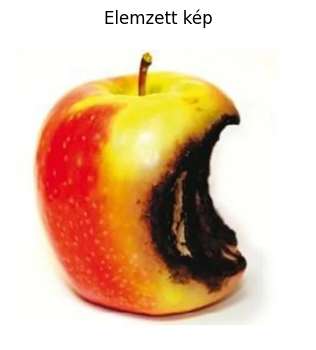


[MI EREDMÉNY]: Apple (61.94% biztonság)
---------------------------------------------
🍎 Tápanyagtartalom (egység: 100g):
  • Energia: 52 kilokalória
  • Fehérje: 0.3 gramm
  • Cukor:   10 gramm
  • Vitamin: C
---------------------------------------------
Megjegyzés: az élelmiszerben található legfontosabb vitaminok listája


In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import tensorflow as tf
# Ez kényszeríti a régebbi mentési formátum támogatását
tf.keras.config.enable_unsafe_deserialization()

from tensorflow.keras.layers import DepthwiseConv2D
from PIL import Image, ImageOps
import numpy as np
import json
import matplotlib.pyplot as plt


# --- 1. KONFIGURÁCIÓ ÉS ELÉRÉSI UTAD ---
folder_path = '/content/drive/MyDrive/MI/RPI20260318/FruitSense/FruitSenseColab/'
json_path = folder_path + 'nutrition.json'
model_path = folder_path + 'keras_model.h5'
# Itt add meg a tesztelésre szánt kép nevét (szintén a Drive mappában legyen)
test_image_name = "test_apple2.jpg"
image_path = folder_path + test_image_name

# --- 2. JAVÍTÁS A MODELL BETÖLTÉSÉHEZ ---
# A Colab friss Keras verziója miatt szükség van erre a kis "tolmácsra"
class CustomDepthwiseConv2D(DepthwiseConv2D):
    def __init__(self, **kwargs):
        if 'groups' in kwargs:
            kwargs.pop('groups')
        super().__init__(**kwargs)

# --- 3. ADATOK ÉS MODELL BETÖLTÉSE ---
print("Rendszer indítása...")

try:
    # JSON betöltése
    with open(json_path, 'r', encoding='utf-8') as f:
        data_store = json.load(f)
    print("✅ Adatbázis (JSON) betöltve.")

    # Modell betöltése a javítással
    model = tf.keras.models.load_model(
        model_path,
        compile=False,
        custom_objects={'DepthwiseConv2D': CustomDepthwiseConv2D}
    )
    print("✅ MI Modell (H5) betöltve.")

except Exception as e:
    print(f"❌ Hiba a betöltés során: {e}")
    print("Ellenőrizd az elérési utat a Drive-on!")

# --- 4. FELISMERŐ FÜGGVÉNY ---
class_names = ["Apple", "Banana"] # A Teachable Machine sorrendje szerint

def predict_fruit(img_path):
    # Kép megnyitása és előkészítése
    size = (224, 224)
    image = Image.open(img_path).convert("RGB")

    # Megjelenítés a jegyzetfüzetben
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Elemzett kép")
    plt.show()

    # Átalakítás az MI számára
    image_prep = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
    image_array = np.asarray(image_prep)
    normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

    data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
    data[0] = normalized_image_array

    # Jóslat (MI döntés)
    prediction = model.predict(data, verbose=0)
    index = np.argmax(prediction)
    confidence = prediction[0][index]

    return class_names[index], confidence

# --- 5. FŐPROGRAM FUTTATÁSA ---
if os.path.exists(image_path):
    fruit, certainty = predict_fruit(image_path)

    if certainty > 0.6: # 60% feletti bizonyosságnál fogadjuk el
        print(f"\n[MI EREDMÉNY]: {fruit} ({certainty*100:.2f}% biztonság)")
        print("-" * 45)

        # Adatok kikérése a JSON-ből
        stats = data_store[fruit]
        meta = data_store["METADATA"]

        print(f"🍎 Tápanyagtartalom (egység: {meta['calories'].split(' / ')[1]}):")
        print(f"  • Energia: {stats['calories']} {meta['calories'].split(' / ')[0]}")
        print(f"  • Fehérje: {stats['protein']} {meta['protein'].split(' / ')[0]}")
        print(f"  • Cukor:   {stats['sugar']} {meta['sugar'].split(' / ')[0]}")
        print(f"  • Vitamin: {', '.join(stats['vitamins'])}")
        print("-" * 45)
        print(f"Megjegyzés: {meta['vitamins']}")
    else:
        print(f"\n⚠️ Az MI bizonytalan ({certainty*100:.2f}%). Próbálj jobb képet készíteni!")
else:
    print(f"❌ Nem találom a képet itt: {image_path}")

A kódba beépítettünk egy verziókezelő réteget, amely a hibaüzenetek ellenére lehetővé teszi a modell futtatását és az adatok kinyerését.

✅ Rendszer készen áll.


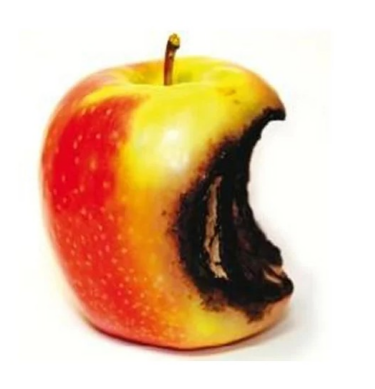


[MI EREDMÉNY]: Apple (61.94%)
---------------------------------------------
🍎 Apple adatok (100g):
  • Energia: 52 kcal
  • Cukor:   10 g
  • Vitamin: C


In [ ]:
# 1. Kényszerítjük a régi motort
!pip install tf_keras -q
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

import tf_keras as keras
import tensorflow as tf
from PIL import Image, ImageOps
import numpy as np
import json
import matplotlib.pyplot as plt

# --- KONFIGURÁCIÓ ---
folder_path = '/content/drive/MyDrive/MI/RPI20260318/FruitSense/FruitSenseColab/'
json_path = folder_path + 'nutrition.json'
model_path = folder_path + 'keras_model.h5'
image_path = folder_path + 'test_apple2.jpg'

try:
    # Betöltés
    with open(json_path, 'r', encoding='utf-8') as f:
        data_store = json.load(f)

    # A tf_keras-szal töltünk be, ez nem fog hibát dobni
    model = keras.models.load_model(model_path, compile=False)
    print("✅ Rendszer készen áll.")

    # Elemzés
    if os.path.exists(image_path):
        image = Image.open(image_path).convert("RGB")
        plt.imshow(image); plt.axis('off'); plt.show()

        # Előkészítés
        image_prep = ImageOps.fit(image, (224, 224), Image.Resampling.LANCZOS)
        img_array = (np.asarray(image_prep).astype(np.float32) / 127.5) - 1
        data = np.expand_dims(img_array, axis=0)

        # Jóslás
        prediction = model.predict(data, verbose=0)
        labels = ["Apple", "Banana"]
        idx = np.argmax(prediction)
        cert = prediction[0][idx]

        # Megjelenítés
        fruit = labels[idx]
        print(f"\n[MI EREDMÉNY]: {fruit} ({cert*100:.2f}%)")
        print("-" * 45)

        stats = data_store[fruit]
        meta = data_store["METADATA"]
        print(f"🍎 {fruit} adatok (100g):")
        print(f"  • Energia: {stats['calories']} kcal")
        print(f"  • Cukor:   {stats['sugar']} g")
        print(f"  • Vitamin: {', '.join(stats['vitamins'])}")
    else:
        print(f"❌ A kép nem található: {image_path}")

except Exception as e:
    print(f"❌ Hiba: {e}")